# Walmart Sales Forecasting Project

## Purpose
This notebook aims to analyze historical sales data from Walmart, preprocess it, perform exploratory data analysis (EDA), train a machine learning model to forecast weekly sales, and provide an interactive tool for predicting future sales for individual stores. The ultimate goal is to optimize inventory management and operational planning.

## 1. Importing required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading and Initial Inspection
This section handles loading the dataset and performing initial checks to understand its structure, identify missing values, and check for duplicates.

In [ ]:
# Load the dataset
df = pd.read_csv('/content/Walmart (1).csv')

### Displaying the first few rows

In [ ]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


### Checking Data Types and Non-Null Counts

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


### Checking for Missing Values

In [ ]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


### Checking for Duplicate Rows

In [ ]:
df.duplicated().sum()

np.int64(0)

## 3. Data Preprocessing
This section focuses on converting the 'Date' column to the correct datetime format, which is crucial for time-series analysis and feature engineering.

In [ ]:
# Basic preprocessing: Convert Date to datetime objects
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

### Displaying the dataframe after date conversion

In [ ]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


### Verifying the data types after conversion

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


## 4. Exploratory Data Analysis (EDA)
This section explores the data to uncover patterns, trends, and relationships between variables, particularly focusing on sales distribution across stores and over time.

In [ ]:
df["Store"].nunique()

45

### Weekly Sales Distribution Across Stores
This bar plot visualizes the total weekly sales for each store, allowing us to identify high-performing and low-performing stores.

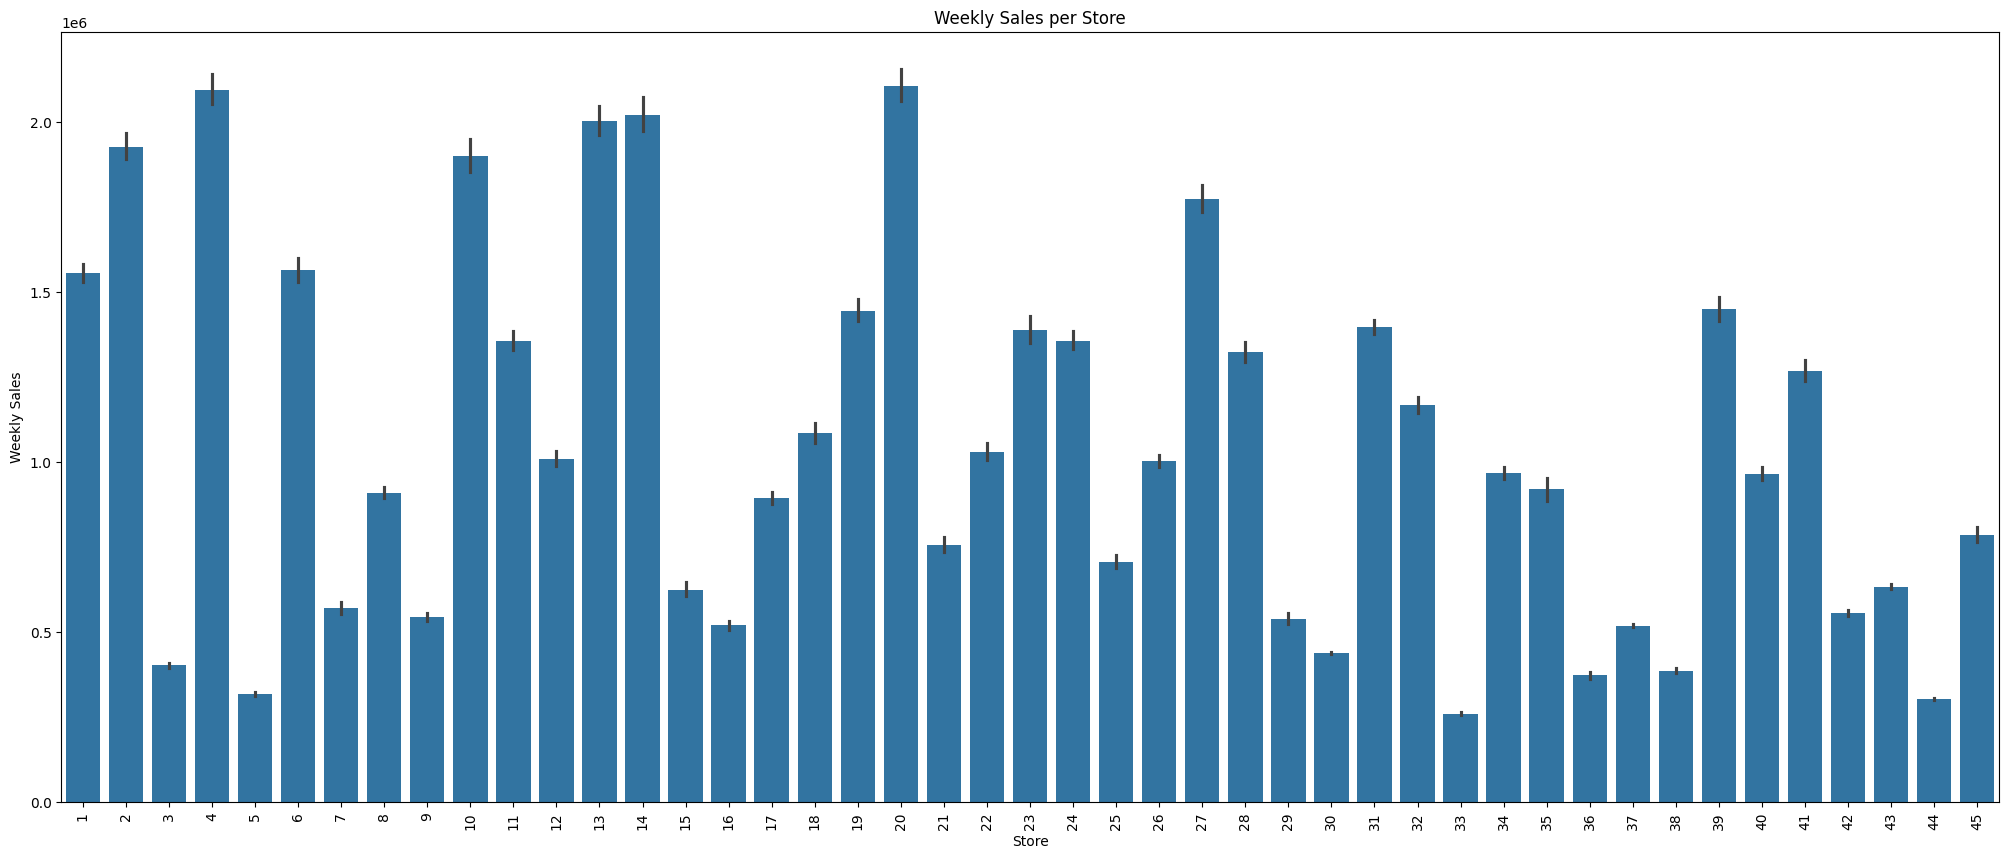

In [ ]:
plt.figure(figsize=(25, 10))
sns.barplot(data=df, x="Store", y="Weekly_Sales")
plt.title("Weekly Sales per Store")
plt.xlabel("Store")
plt.ylabel("Weekly Sales")
plt.xticks(rotation=90)

plt.show()

### Total Weekly Sales Trend Across All Stores
This line plot shows the aggregate weekly sales over time for all stores combined, helping to identify overall sales trends and seasonality.

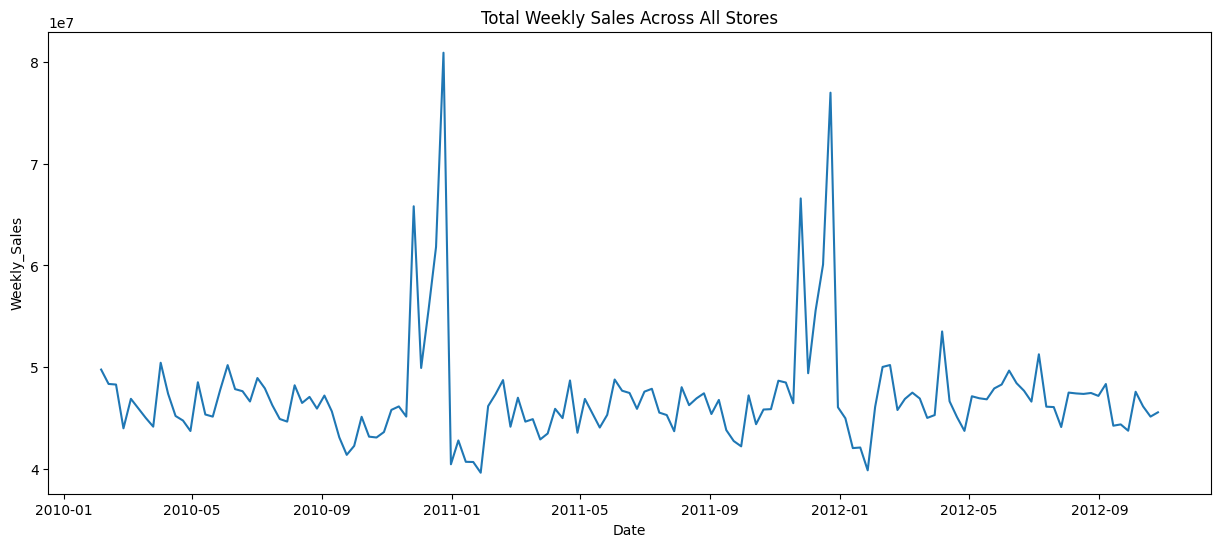

In [ ]:
# Exploratory Data Analysis: Weekly Sales Trend
plt.figure(figsize=(15, 6))
df_total_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
sns.lineplot(data=df_total_sales, x='Date', y='Weekly_Sales')
plt.title('Total Weekly Sales Across All Stores')
plt.show()

## 5. Feature Engineering
In this section, we extract additional time-based features (Year, Month, Week) from the 'Date' column. These features can help the model capture seasonal and annual patterns in sales data.

In [ ]:
# Feature Engineering: Extract time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

### Displaying the DataFrame with New Features

In [ ]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9


## 6. Splitting Data into Training and Testing Sets
- We define the features (input variables) and the target variable ('Weekly_Sales') and split the data into training and testing sets.

In [ ]:
# Define features and target
features = ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week']
X = df[features]
y = df['Weekly_Sales']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 7. Model Training
This section sets up the machine learning model and then trains a RandomForestRegressor model.

### Initializing and Training the Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
# Train Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## 8. Model Evaluation
After training, the model's performance is evaluated on the test set using key metrics such as R² score and Mean Absolute Error (MAE). This helps us understand how well the model generalises to unseen data.

In [ ]:
# Evaluate
y_pred = rf_model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")

R2 Score: 0.9596
MAE: 62022.51


## 9. Sales Forecasting Function
This section defines a reusable function `forecast_next_12_weeks` that takes a store ID as input and generates a 12-week sales forecast using the trained Random Forest Regressor. It handles feature engineering for future dates and incorporates holiday flags.

In [ ]:
def forecast_next_12_weeks(store_id):
    last_date = df['Date'].max()
    forecast_dates = pd.date_range(start=last_date + pd.Timedelta(weeks=1), periods=12, freq='W')

    # Get last known values for environmental features
    last_row = df[df['Store'] == store_id].iloc[-1]

    forecast_df = pd.DataFrame({
        'Store': store_id,
        'Date': forecast_dates,
        'Holiday_Flag': 0, # Initialize to 0
        'Temperature': last_row['Temperature'],
        'Fuel_Price': last_row['Fuel_Price'],
        'CPI': last_row['CPI'],
        'Unemployment': last_row['Unemployment']
    })

    forecast_df['Year'] = forecast_df['Date'].dt.year
    forecast_df['Month'] = forecast_df['Date'].dt.month
    forecast_df['Week'] = forecast_df['Date'].dt.isocalendar().week.astype(int)

    holiday_weeks_for_forecast = {47, 52}
    forecast_df['Holiday_Flag'] = forecast_df['Week'].apply(lambda x: 1 if x in holiday_weeks_for_forecast else 0)

    preds = rf_model.predict(forecast_df[features])
    forecast_df['Predicted_Sales'] = preds
    return forecast_df[['Date', 'Predicted_Sales']]

## 10. Interactive Forecasting and Visualisation
This section provides an interactive way to forecast sales for any store. Users can enter a store ID, and the notebook will display the 12-week forecast and visualise it alongside historical sales for that store.

In [ ]:
# Forecast for Store 1
store_1_forecast = forecast_next_12_weeks(1)
print("12-Week Forecast for Store 1:")
print(store_1_forecast)

12-Week Forecast for Store 1:
         Date  Predicted_Sales
0  2012-11-04     1.525789e+06
1  2012-11-11     1.525789e+06
2  2012-11-18     1.553572e+06
3  2012-11-25     1.836549e+06
4  2012-12-02     1.831427e+06
5  2012-12-09     1.824597e+06
6  2012-12-16     1.893250e+06
7  2012-12-23     1.963551e+06
8  2012-12-30     1.812084e+06
9  2013-01-06     1.600814e+06
10 2013-01-13     1.596194e+06
11 2013-01-20     1.591573e+06


### Visualization of Store 1 Forecast vs Historical

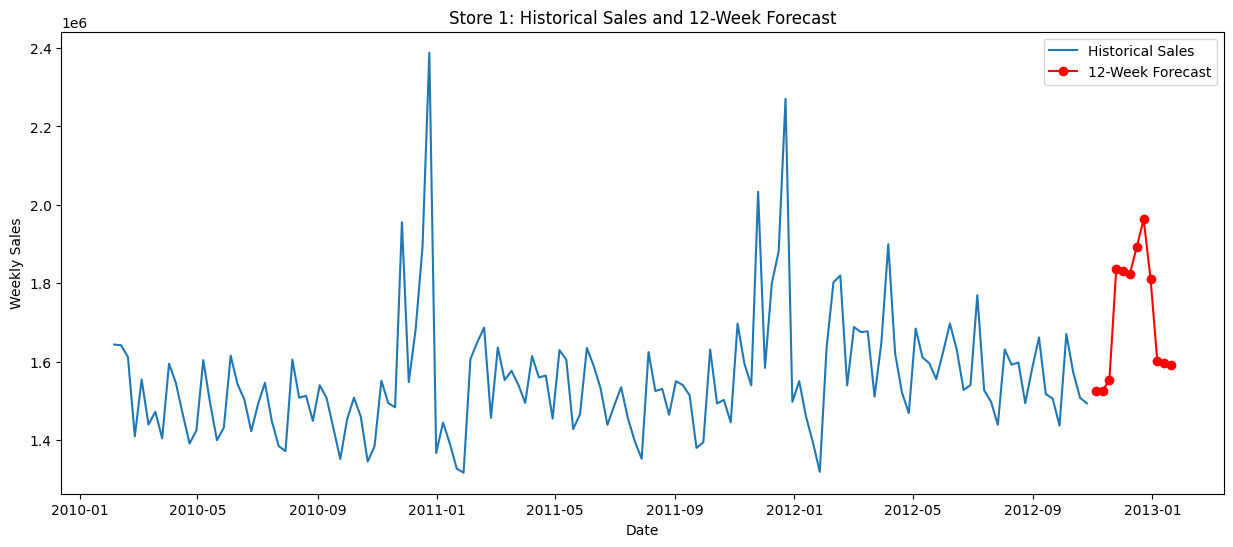

In [ ]:
# Visualize Forecast vs Historical for Store 1
plt.figure(figsize=(15, 6))
historical_store1 = df[df['Store'] == 1]
plt.plot(historical_store1['Date'], historical_store1['Weekly_Sales'], label='Historical Sales')
plt.plot(store_1_forecast['Date'], store_1_forecast['Predicted_Sales'], label='12-Week Forecast', color='red', marker='o')
plt.title('Store 1: Historical Sales and 12-Week Forecast')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()

## 9. Insights and Recommendations
Based on the model's performance and data analysis, this section summarizes key insights and provides actionable recommendations for inventory management and business strategy.

### Interactive Sales Forecasting

Enter a store ID below to get a 12-week sales forecast for that store.

Enter the Store ID for which you want to forecast sales : 4

12-Week Forecast for Store 4:


,Date,Predicted_Sales
0,2012-11-04,2.043118e+06
1,2012-11-11,2.042835e+06
2,2012-11-18,2.043047e+06
3,2012-11-25,2.641929e+06
4,2012-12-02,2.103309e+06
5,2012-12-09,2.330081e+06
6,2012-12-16,2.436184e+06
7,2012-12-23,3.297357e+06
8,2012-12-30,1.880942e+06
9,2013-01-06,1.921911e+06


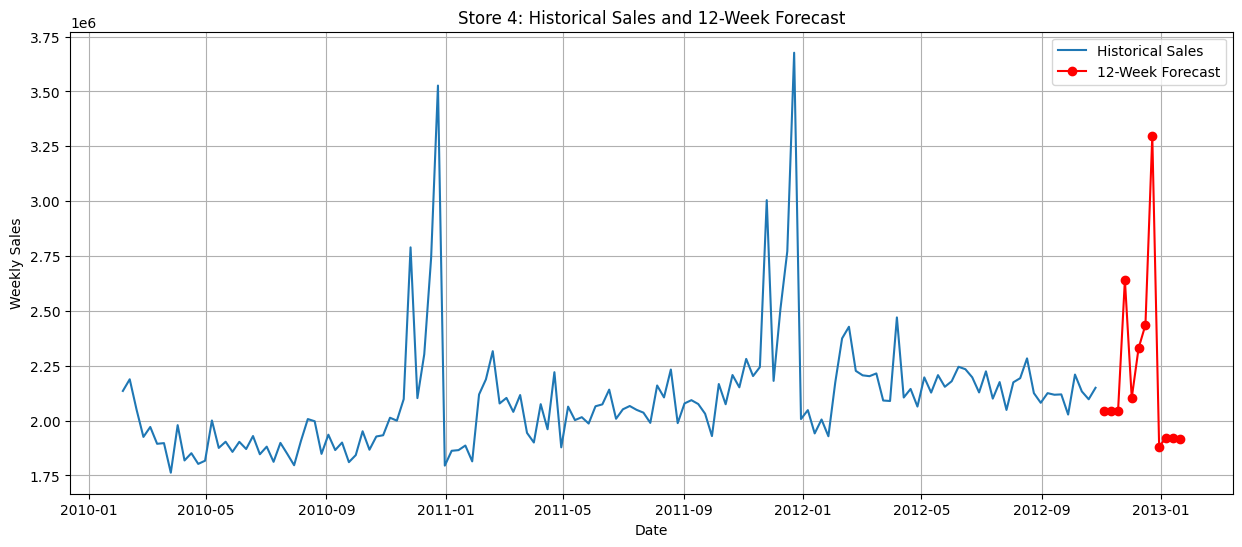

In [ ]:
try:
    store_id_input = int(input("Enter the Store ID for which you want to forecast sales : "))
    if 1 <= store_id_input <= 45:
        user_forecast = forecast_next_12_weeks(store_id_input)
        print(f"\n12-Week Forecast for Store {store_id_input}:")
        display(user_forecast)

        # Visualize Forecast vs Historical for the selected Store
        plt.figure(figsize=(15, 6))
        historical_store = df[df['Store'] == store_id_input]
        plt.plot(historical_store['Date'], historical_store['Weekly_Sales'], label='Historical Sales')
        plt.plot(user_forecast['Date'], user_forecast['Predicted_Sales'], label='12-Week Forecast', color='red', marker='o')
        plt.title(f'Store {store_id_input}: Historical Sales and 12-Week Forecast')
        plt.xlabel('Date')
        plt.ylabel('Weekly Sales')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("Please enter a Store ID between 1 and 45.")
except ValueError:
    print("Invalid input. Please enter a valid integer for the Store ID.")


### Insights and Recommendations
1. **Seasonality:** The model captures significant sales spikes during the end-of-year weeks (Weeks 47-52), suggesting that stores should increase inventory levels starting in early November.
2. **Feature Importance:** Time-based features (Week and Month) and store location are the primary drivers of sales variance. Environmental factors like CPI and Unemployment show steady trends but have less impact on short-term weekly fluctuations.
3. **Inventory Management:** By utilizing these forecasts, store managers can align supply with demand, reducing stockouts during peak periods and minimizing overstock during the quieter January period shown in the forecast.